In [20]:
# ============================================================
# MADI v5 shard verification notebook
# Run per-shard sanity checks while the production build is
# still in progress. Point SHARD_DIR at wherever completed
# shards land (e.g. libraries/ synced from Sol, or a local
# mount). Safe to re-run as more shards complete.
# ============================================================

import glob
import os
import numpy as np
import matplotlib.pyplot as plt

SHARD_DIR = "libraries"
SHARD_GLOB = "madi_dense_universal_remediated.shard*.npz"
shard_paths = ["C:\\Miscellaneous\\Coding_Projects\\Python\\mri_processing\\processing\\madi_gpu\\Custom_MADI\\libraries\\madi_dense_universal_remediated.shard003.npz"]
TRUST_FLOOR = 0.015      # S/S0 below this is not to be trusted
N_ENSEMBLES = 40
N_SUBSET_COLUMNS = 200

# shard_paths = sorted(glob.glob(os.path.join(SHARD_DIR, SHARD_GLOB)))
print(f"Found {len(shard_paths)} shard(s) in {SHARD_DIR!r}")
for p in shard_paths[:5]:
    print("  ", os.path.basename(p))
if len(shard_paths) > 5:
    print(f"  ... and {len(shard_paths) - 5} more")

Found 1 shard(s) in 'libraries'
   madi_dense_universal_remediated.shard003.npz


In [27]:
# ------------------------------------------------------------
# Cell 2: load one shard for close inspection
#
# Change SHARD_INDEX to look at a different completed shard.
# ------------------------------------------------------------

SHARD_INDEX = 0
assert shard_paths, "No shards found yet — check SHARD_DIR."

shard_path = shard_paths[SHARD_INDEX]
print(f"Loading {shard_path}")

with np.load(shard_path, allow_pickle=True) as data:
    print("\nArrays in this shard:")
    for key in data.files:
        arr = data[key]
        print(f"  {key:24s} shape={str(arr.shape):20s} dtype={arr.dtype}")

    vectors = data["vectors"]
    signal_imag = data["signal_imag"]
    signal_variance = data["signal_variance"]
    ensemble_means_subset = data["ensemble_means_subset"]
    rhos = data["rhos"]
    Vs = data["Vs"]
    kios = data["kios"]
    nominal_rhos = data["nominal_rhos"]
    nominal_Vs = data["nominal_Vs"]
    nominal_kios = data["nominal_kios"]

    # metadata may be stored as a JSON string under a few
    # possible keys depending on build version — grab whichever
    # is present rather than assuming one name.
    meta = None
    for meta_key in ("build_metadata"):
        if meta_key in data.files:  
            import json
            raw = data[meta_key]
            raw = raw.item() if hasattr(raw, "item") else raw
            meta = json.loads(raw) if isinstance(raw, (str, bytes)) else raw
            print(f"  {meta_key:24s} shape={str(meta.shape):20s} dtype={meta.dtype}")
            break

n_entries, n_columns = vectors.shape
print(f"\n{n_entries} entries x {n_columns} columns in this shard")

Loading C:\Miscellaneous\Coding_Projects\Python\mri_processing\processing\madi_gpu\Custom_MADI\libraries\madi_dense_universal_remediated.shard003.npz

Arrays in this shard:
  library_schema           shape=()                   dtype=<U15
  kios                     shape=(51,)                dtype=float64
  rhos                     shape=(51,)                dtype=float64
  Vs                       shape=(51,)                dtype=float64
  vis                      shape=(51,)                dtype=float64
  vectors                  shape=(51, 31125)          dtype=float64
  nominal_kios             shape=(51,)                dtype=float64
  nominal_rhos             shape=(51,)                dtype=float64
  nominal_Vs               shape=(51,)                dtype=float64
  weights                  shape=(51,)                dtype=float64
  has_weights              shape=()                   dtype=bool
  pps                      shape=(51,)                dtype=float64
  kio_analytic_eq

In [11]:
# ------------------------------------------------------------
# Cell 3: realized-label sanity check
#
# Each shard should be exactly one (rho, V) geometry group:
# rho and V identical across all entries (bit-identical, since
# geometry is built once and reused across the k_io sweep),
# with k_io varying across the 51-value grid.
# ------------------------------------------------------------

rho_unique = np.unique(rhos)
V_unique = np.unique(Vs)

print(f"Unique realized rho values in shard: {len(rho_unique)}")
print(f"Unique realized V values in shard:   {len(V_unique)}")

if len(rho_unique) == 1 and len(V_unique) == 1:
    print(f"  -> single geometry group, as expected")
    print(f"     rho = {rho_unique[0]:,.3f} cells/uL")
    print(f"     V   = {V_unique[0]:.6f} pL")
    v_i = rho_unique[0] * V_unique[0] * 1e-6
    print(f"     v_i = {v_i:.5f}")
else:
    print("  !! WARNING: this shard spans more than one (rho, V) pair. "
          "Expected exactly one per shard (or the free-water atom).")

print(f"\nk_io range: {kios.min():.3f} to {kios.max():.3f} s^-1, "
      f"{len(np.unique(kios))} unique values")

# Free-water atom check: rho == 0 or V == 0 marks it, if present
is_free_water = (rhos == 0) | (Vs == 0)
if is_free_water.any():
    print(f"\nFree-water atom present: {is_free_water.sum()} entry (entries)")

Unique realized rho values in shard: 1
Unique realized V values in shard:   1
  -> single geometry group, as expected
     rho = 9,950.665 cells/uL
     V   = 66.917403 pL
     v_i = 0.66587

k_io range: 0.000 to 130.000 s^-1, 51 unique values


In [24]:
# ------------------------------------------------------------
# Cell 4: array-level finiteness and basic value checks
#
# Every array should be fully finite. signal_variance must be
# non-negative everywhere. b=0 should be exactly 1.0 in every
# entry (deterministic, no walk needed to know S(b=0)=1).
# ------------------------------------------------------------

def report_finite(name, arr):
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    status = "OK" if (n_nan == 0 and n_inf == 0) else "FAIL"
    print(f"  [{status}] {name:24s} NaN={n_nan:<8d} Inf={n_inf}")
    return n_nan == 0 and n_inf == 0

print("Finiteness checks:")
ok = True
ok &= report_finite("vectors", vectors)
ok &= report_finite("signal_imag", signal_imag)
ok &= report_finite("signal_variance", signal_variance)
ok &= report_finite("ensemble_means_subset", ensemble_means_subset)

print(f"\nsignal_variance non-negativity: "
      f"{'OK' if (signal_variance >= 0).all() else 'FAIL'} "
      f"(min = {signal_variance.min():.3e})")

# b=0 is stored as the first b-value in each (delta,Delta) block.
# If the column layout metadata is available, use it; otherwise
# fall back to the documented pair-major/b-major layout with
# b=0 as the first of 25 b-values per pair.
N_B = 25
b0_columns = vectors[:, 0::N_B]
print(f"\nS(b=0) check across all {b0_columns.shape[1]} timing pairs:")
print(f"  min={b0_columns.min():.10f}  max={b0_columns.max():.10f}  "
      f"({'OK, exactly 1.0' if np.allclose(b0_columns, 1.0, atol=1e-12) else 'FAIL — not exactly 1.0'})")

Finiteness checks:
  [OK] vectors                  NaN=0        Inf=0
  [OK] signal_imag              NaN=0        Inf=0
  [OK] signal_variance          NaN=0        Inf=0
  [OK] ensemble_means_subset    NaN=0        Inf=0

signal_variance non-negativity: OK (min = 0.000e+00)

S(b=0) check across all 1245 timing pairs:
  min=1.0000000000  max=1.0000000000  (OK, exactly 1.0)


In [ ]:
# ------------------------------------------------------------
# Cell 5: subset reconstruction check
#
# ensemble_means_subset holds 40 per-ensemble means for 200
# declared diagnostic columns. Averaging over the ensemble
# axis must reproduce the corresponding columns of `vectors`
# to within float32 rounding. This is the single strongest
# check that the diagnostic subset is correctly indexed —
# if pair-major/b-major ordering were scrambled, this would
# fail by ~1e-2 to 1, not ~1e-7.
#
# NOTE: this assumes the subset columns are the first
# N_SUBSET_COLUMNS columns of `vectors` in matching order.
# If your build stores an explicit column-index map for the
# subset, load and use it instead of this assumption.
# ------------------------------------------------------------

full_pairs = list(zip(data["pair_deltas"].astype(float),
                    data["pair_Deltas"].astype(float)))
subset_pairs = list(zip(data["ensemble_subset_pair_deltas"].astype(float),
                        data["ensemble_subset_pair_Deltas"].astype(float)))

full_b = data["b_values"].astype(float)
subset_b = data["ensemble_subset_b_values"].astype(float)
n_b = int(data["n_b"])

pair_index = {pair: i for i, pair in enumerate(full_pairs)}
b_index = {float(b): i for i, b in enumerate(full_b)}

subset_columns = np.array([
    pair_index[pair] * n_b + b_index[float(b)]
    for pair in subset_pairs
    for b in subset_b
], dtype=np.int64)

subset_ref = vectors[:, subset_columns]
subset_mean = ensemble_means_subset.mean(axis=1)          # (n_entries, 200)

abs_err = np.abs(subset_mean - subset_ref)
print(f"Subset reconstruction error over {abs_err.size:,} values:")
print(f"  max abs error  = {abs_err.max():.3e}")
print(f"  mean abs error = {abs_err.mean():.3e}")
print(f"  {'OK' if abs_err.max() < 1e-6 else 'FAIL — check column ordering assumption above'}")



AttributeError: 'NoneType' object has no attribute 'open'

In [14]:
# ------------------------------------------------------------
# Cell 6: negative and out-of-range signal tail
#
# Signal cannot physically be negative or exceed S(b=0)=1.
# Small negative excursions at high b are expected Monte Carlo
# noise around a true value near zero, not evidence of a bug —
# but they should be small and rare at production statistics
# (6M axis-walks -> sigma_MC ~ 4.1e-4).
# ------------------------------------------------------------

neg_mask = vectors < 0
over_mask = vectors > 1.0 + 1e-9

print(f"Negative values: {neg_mask.sum():,} / {vectors.size:,} "
      f"({100*neg_mask.sum()/vectors.size:.4f}%)")
if neg_mask.any():
    print(f"  most negative: {vectors[neg_mask].min():.3e}")
    print(f"  (nominal sigma_MC at 6M axis-walks: {1/np.sqrt(6_000_000):.3e} "
          f"— compare to gauge severity)")

print(f"\nValues above 1.0: {over_mask.sum():,} / {vectors.size:,}")
if over_mask.any():
    print(f"  max: {vectors[over_mask].max():.6f}")

print(f"\nColumns below trust floor ({TRUST_FLOOR}): "
      f"{(vectors < TRUST_FLOOR).sum():,} / {vectors.size:,} "
      f"({100*(vectors < TRUST_FLOOR).mean():.2f}%)")

Negative values: 179,527 / 1,587,375 (11.3097%)
  most negative: -1.093e-03
  (nominal sigma_MC at 6M axis-walks: 4.082e-04 — compare to gauge severity)

Values above 1.0: 0 / 1,587,375

Columns below trust floor (0.015): 1,279,574 / 1,587,375 (80.61%)


Standardized |signal_imag| / SE(real):
  max  = 5.790
  95th percentile = 2.072
  (compare against your declared family-wise threshold, e.g. the pilot's t-based bound)


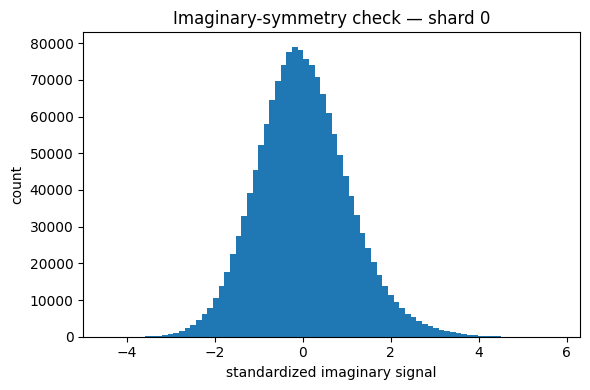

In [15]:
# ------------------------------------------------------------
# Cell 7: imaginary-signal symmetry check
#
# signal_imag should be noise around zero by symmetry. Report
# the standardized statistic per column and flag anything far
# outside what 40-ensemble sampling noise would produce.
# ------------------------------------------------------------

se_real = np.sqrt(signal_variance / N_ENSEMBLES)
se_real_safe = np.where(se_real > 0, se_real, np.nan)  # avoid div-by-zero at b=0

standardized_imag = signal_imag / se_real_safe
finite_std = standardized_imag[np.isfinite(standardized_imag)]

print(f"Standardized |signal_imag| / SE(real):")
print(f"  max  = {np.nanmax(np.abs(finite_std)):.3f}")
print(f"  95th percentile = {np.nanpercentile(np.abs(finite_std), 95):.3f}")
print(f"  (compare against your declared family-wise threshold, "
      f"e.g. the pilot's t-based bound)")

plt.figure(figsize=(6, 4))
plt.hist(finite_std, bins=80)
plt.xlabel("standardized imaginary signal")
plt.ylabel("count")
plt.title(f"Imaginary-symmetry check — shard {SHARD_INDEX}")
plt.tight_layout()
plt.show()

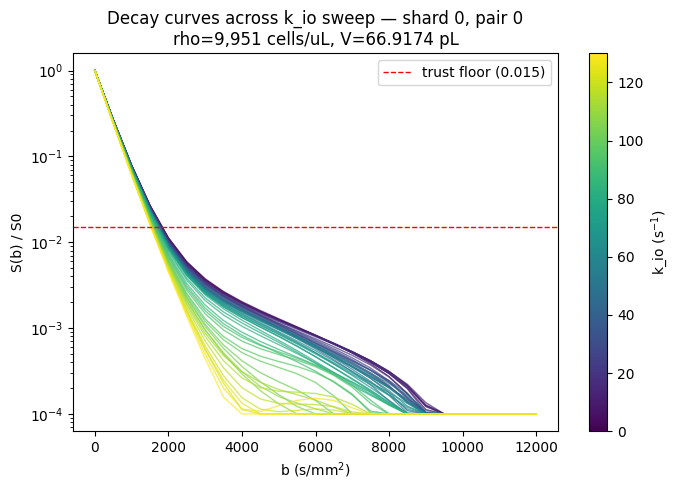

In [16]:
# ------------------------------------------------------------
# Cell 8: one decay curve — sanity plot
#
# Pick one timing pair and plot S(b)/S0 across the k_io sweep
# for this shard's (rho, V). Expect: curved (non-Gaussian) in
# semilog-y, and faster/straighter decay as k_io increases
# (higher membrane permeability -> more Gaussian-like, matches
# MADI I Fig. 4a).
# ------------------------------------------------------------

# Adjust this to whatever (delta, Delta) pair index you want;
# 0 is the first stored timing pair.
PAIR_INDEX = 0
b_values = np.arange(0, 12001, 500)  # production b grid, 25 points

col_start = PAIR_INDEX * N_B
col_end = col_start + N_B
decay_block = vectors[:, col_start:col_end]  # (n_entries, 25)

order = np.argsort(kios)

plt.figure(figsize=(7, 5))
cmap = plt.cm.viridis
for rank, idx in enumerate(order):
    color = cmap(rank / max(len(order) - 1, 1))
    plt.semilogy(b_values, np.clip(decay_block[idx], 1e-4, None),
                 color=color, alpha=0.7, lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=kios.min(), vmax=kios.max()))
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("k_io (s$^{-1}$)")

plt.axhline(TRUST_FLOOR, color="red", ls="--", lw=1, label=f"trust floor ({TRUST_FLOOR})")
plt.xlabel("b (s/mm$^2$)")
plt.ylabel("S(b) / S0")
plt.title(f"Decay curves across k_io sweep — shard {SHARD_INDEX}, pair {PAIR_INDEX}\n"
          f"rho={rho_unique[0]:,.0f} cells/uL, V={V_unique[0]:.4f} pL")
plt.legend()
plt.tight_layout()
plt.show()

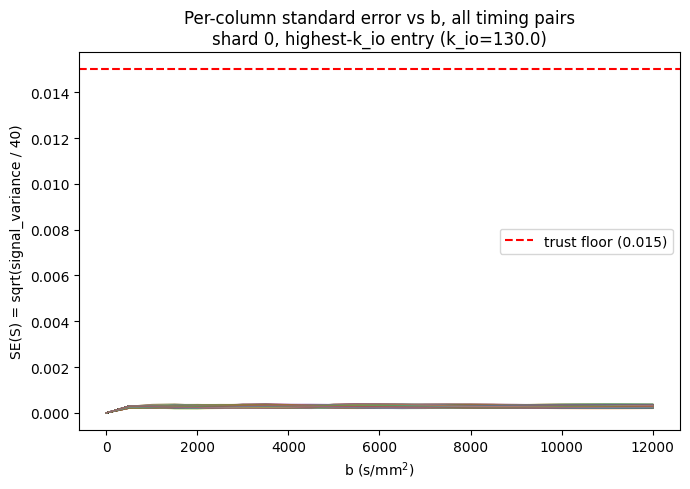

In [17]:
# ------------------------------------------------------------
# Cell 9: noise floor vs b — where does the library stop
# being trustworthy?
#
# Plots the per-column standard error against b, for every
# stored timing pair, alongside the trust floor. Points where
# the SE is a large fraction of the trust floor are the ones
# worth excluding at fit time.
# ------------------------------------------------------------

# reshape to (n_entries, n_pairs, n_b) for easy slicing
n_pairs = n_columns // N_B
se_reshaped = se_real.reshape(n_entries, n_pairs, N_B)
signal_reshaped = vectors.reshape(n_entries, n_pairs, N_B)

# pick the highest-k_io entry (fastest decay, most likely to
# dip toward the trust floor at high b) for a representative look
fast_idx = np.argmax(kios)

plt.figure(figsize=(7, 5))
for pair_idx in range(n_pairs):
    plt.plot(b_values, se_reshaped[fast_idx, pair_idx], alpha=0.4, lw=0.8)

plt.axhline(TRUST_FLOOR, color="red", ls="--", lw=1.5, label=f"trust floor ({TRUST_FLOOR})")
plt.xlabel("b (s/mm$^2$)")
plt.ylabel("SE(S) = sqrt(signal_variance / 40)")
plt.title(f"Per-column standard error vs b, all timing pairs\n"
          f"shard {SHARD_INDEX}, highest-k_io entry (k_io={kios[fast_idx]:.1f})")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ------------------------------------------------------------
# Cell 10: batch check across every completed shard
#
# Runs the cheap checks (finiteness, S(b=0)=1, subset
# reconstruction, negative-tail rate, single-geometry-group
# property) over every shard found in Cell 1, and prints a
# one-line summary per shard. Re-run this as more shards land.
# ------------------------------------------------------------

def check_shard(path, n_subset_columns=N_SUBSET_COLUMNS, n_ensembles=N_ENSEMBLES, n_b=N_B):
    issues = []
    with np.load(path) as data:
        vec = data["vectors"]
        s_imag = data["signal_imag"]
        s_var = data["signal_variance"]
        ens_sub = data["ensemble_means_subset"]
        rho = data["rhos"]
        V = data["Vs"]
        kio = data["kios"]

    if not np.isfinite(vec).all():
        issues.append("vectors not finite")
    if not np.isfinite(s_imag).all():
        issues.append("signal_imag not finite")
    if not np.isfinite(s_var).all():
        issues.append("signal_variance not finite")
    if (s_var < 0).any():
        issues.append("negative signal_variance")

    b0 = vec[:, 0::n_b]
    if not np.allclose(b0, 1.0, atol=1e-9):
        issues.append(f"S(b=0) != 1 (max dev {np.abs(b0 - 1.0).max():.2e})")

    is_fw = (rho == 0) | (V == 0)
    non_fw = ~is_fw
    if non_fw.any():
        if len(np.unique(rho[non_fw])) > 1 or len(np.unique(V[non_fw])) > 1:
            issues.append("multiple (rho,V) groups in one shard")

    subset_mean = ens_sub.mean(axis=1)
    subset_ref = vec[:, :n_subset_columns]
    max_err = np.abs(subset_mean - subset_ref).max()
    if max_err > 1e-6:
        issues.append(f"subset reconstruction error {max_err:.2e}")

    neg_frac = (vec < 0).mean()

    return {
        "path": os.path.basename(path),
        "n_entries": vec.shape[0],
        "neg_frac": neg_frac,
        "subset_err": max_err,
        "issues": issues,
    }

print(f"{'shard':40s} {'entries':>8s} {'neg%':>8s} {'subset_err':>12s}  status")
print("-" * 90)

all_ok = True
for path in shard_paths:
    result = check_shard(path)
    status = "OK" if not result["issues"] else "FAIL: " + "; ".join(result["issues"])
    all_ok &= not result["issues"]
    print(f"{result['path']:40s} {result['n_entries']:8d} "
          f"{100*result['neg_frac']:7.3f}% {result['subset_err']:12.2e}  {status}")

print("-" * 90)
print(f"\n{'ALL SHARDS PASSED' if all_ok else 'SOME SHARDS FAILED — see above'}")

shard                                     entries     neg%   subset_err  status
------------------------------------------------------------------------------------------
madi_dense_universal_remediated.shard003.npz       51  11.310%     1.63e-01  FAIL: subset reconstruction error 1.63e-01
------------------------------------------------------------------------------------------

SOME SHARDS FAILED — see above
